#  Data Comprehension & Cleaning

In this notebook, we begin by exploring the structure and quality of the rainfall dataset.  
We aim to prepare a clean and reliable dataset that can be used for further analysis and modeling.

We focus on:
- Understanding the dataset structure
- Handling missing and duplicate values
- Feature engineering
- Ensuring data consistency

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [ ]:
import kagglehub

path = kagglehub.dataset_download("rajanand/rainfall-in-india")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'rainfall-in-india' dataset.
Path to dataset files: /kaggle/input/rainfall-in-india


In [ ]:
import os

files = os.listdir(path)
print(files)

['rainfall in india 1901-2015.csv', 'district wise rainfall normal.csv']


In [ ]:
df = pd.read_csv(os.path.join(path, files[0]))
df.head()

,SUBDIVISION,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec
0,ANDAMAN & NICOBAR ISLANDS,1901,49.2,87.1,29.2,2.3,528.8,517.5,365.1,481.1,332.6,388.5,558.2,33.6,3373.2,136.3,560.3,1696.3,980.3
1,ANDAMAN & NICOBAR ISLANDS,1902,0.0,159.8,12.2,0.0,446.1,537.1,228.9,753.7,666.2,197.2,359.0,160.5,3520.7,159.8,458.3,2185.9,716.7
2,ANDAMAN & NICOBAR ISLANDS,1903,12.7,144.0,0.0,1.0,235.1,479.9,728.4,326.7,339.0,181.2,284.4,225.0,2957.4,156.7,236.1,1874.0,690.6
3,ANDAMAN & NICOBAR ISLANDS,1904,9.4,14.7,0.0,202.4,304.5,495.1,502.0,160.1,820.4,222.2,308.7,40.1,3079.6,24.1,506.9,1977.6,571.0
4,ANDAMAN & NICOBAR ISLANDS,1905,1.3,0.0,3.3,26.9,279.5,628.7,368.7,330.5,297.0,260.7,25.4,344.7,2566.7,1.3,309.7,1624.9,630.8


In [ ]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4116 entries, 0 to 4115
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   SUBDIVISION  4116 non-null   object 
 1   YEAR         4116 non-null   int64  
 2   JAN          4112 non-null   float64
 3   FEB          4113 non-null   float64
 4   MAR          4110 non-null   float64
 5   APR          4112 non-null   float64
 6   MAY          4113 non-null   float64
 7   JUN          4111 non-null   float64
 8   JUL          4109 non-null   float64
 9   AUG          4112 non-null   float64
 10  SEP          4110 non-null   float64
 11  OCT          4109 non-null   float64
 12  NOV          4105 non-null   float64
 13  DEC          4106 non-null   float64
 14  ANNUAL       4090 non-null   float64
 15  Jan-Feb      4110 non-null   float64
 16  Mar-May      4107 non-null   float64
 17  Jun-Sep      4106 non-null   float64
 18  Oct-Dec      4103 non-null   float64
dtypes: flo

,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec
count,4116.000000,4112.000000,4113.000000,4110.000000,4112.000000,4113.000000,4111.000000,4109.000000,4112.000000,4110.000000,4109.000000,4105.000000,4106.000000,4090.000000,4110.000000,4107.000000,4106.000000,4103.000000
mean,1958.218659,18.957320,21.805325,27.359197,43.127432,85.745417,230.234444,347.214334,290.263497,197.361922,95.507009,39.866163,18.870580,1411.008900,40.747786,155.901753,1064.724769,154.100487
std,33.140898,33.585371,35.909488,46.959424,67.831168,123.234904,234.710758,269.539667,188.770477,135.408345,99.519134,68.685410,42.369611,903.846565,59.308277,201.316965,707.741531,166.942660
min,1901.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.400000,0.000000,0.000000,0.100000,0.000000,0.000000,0.000000,62.300000,0.000000,0.000000,57.400000,0.000000
25%,1930.000000,0.600000,0.600000,1.000000,3.000000,8.600000,70.350000,175.600000,155.975000,100.525000,14.600000,0.700000,0.100000,804.500000,4.100000,24.050000,573.850000,34.200000
50%,1958.000000,6.000000,6.700000,7.800000,15.700000,36.600000,138.700000,284.800000,259.400000,173.900000,65.200000,9.500000,3.000000,1121.300000,19.200000,74.800000,881.100000,98.200000
75%,1987.000000,22.200000,26.800000,31.300000,49.950000,97.200000,305.150000,418.400000,377.800000,265.800000,148.400000,46.100000,17.500000,1644.775000,50.375000,196.950000,1288.175000,213.500000
max,2015.000000,583.700000,403.500000,605.600000,595.100000,1168.600000,1609.900000,2362.800000,1664.600000,1222.000000,948.300000,648.900000,617.500000,6331.100000,699.500000,1745.800000,4536.900000,1252.500000


In [ ]:
df.isnull().sum()
df = df.fillna(df.median(numeric_only=True))

In [ ]:
df.duplicated().sum()
df = df.drop_duplicates()

In [ ]:
df.columns = df.columns.str.strip().str.lower()
df.rename(columns={
    'subdivision': 'region'
}, inplace=True)

df.head()

,region,year,jan,feb,mar,apr,may,jun,jul,aug,sep,oct,nov,dec,annual,jan-feb,mar-may,jun-sep,oct-dec
0,ANDAMAN & NICOBAR ISLANDS,1901,49.2,87.1,29.2,2.3,528.8,517.5,365.1,481.1,332.6,388.5,558.2,33.6,3373.2,136.3,560.3,1696.3,980.3
1,ANDAMAN & NICOBAR ISLANDS,1902,0.0,159.8,12.2,0.0,446.1,537.1,228.9,753.7,666.2,197.2,359.0,160.5,3520.7,159.8,458.3,2185.9,716.7
2,ANDAMAN & NICOBAR ISLANDS,1903,12.7,144.0,0.0,1.0,235.1,479.9,728.4,326.7,339.0,181.2,284.4,225.0,2957.4,156.7,236.1,1874.0,690.6
3,ANDAMAN & NICOBAR ISLANDS,1904,9.4,14.7,0.0,202.4,304.5,495.1,502.0,160.1,820.4,222.2,308.7,40.1,3079.6,24.1,506.9,1977.6,571.0
4,ANDAMAN & NICOBAR ISLANDS,1905,1.3,0.0,3.3,26.9,279.5,628.7,368.7,330.5,297.0,260.7,25.4,344.7,2566.7,1.3,309.7,1624.9,630.8


### Feature Engineering

Monthly data is aggregated into seasonal components:

- Winter (Jan–Feb)
- Summer (Mar–May)
- Monsoon (Jun–Sep)
- Post-Monsoon (Oct–Dec)

These features help capture broader climatic patterns, useful for later analysis and modeling.

In [ ]:
df['winter'] = df[['jan', 'feb']].sum(axis=1)
df['summer'] = df[['mar', 'apr', 'may']].sum(axis=1)
df['monsoon'] = df[['jun', 'jul', 'aug', 'sep']].sum(axis=1)
df['post_monsoon'] = df[['oct', 'nov', 'dec']].sum(axis=1)

In [ ]:
df['annual_calc'] = df[
    ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
].sum(axis=1)

In [ ]:
(df['annual'] - df['annual_calc']).abs().mean()

np.float64(7.052210884353787)

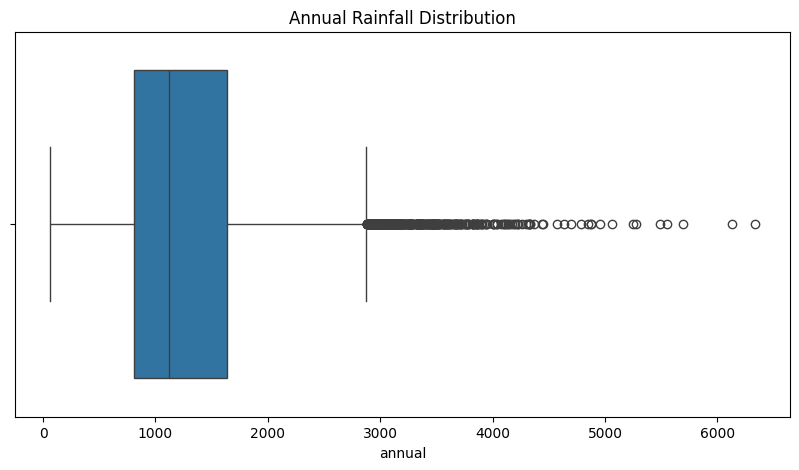

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df['annual'])
plt.title("Annual Rainfall Distribution")
plt.show()

In [ ]:
df.describe()
df.isnull().sum()

,0
region,0
year,0
jan,0
feb,0
mar,0
apr,0
may,0
jun,0
jul,0
aug,0


In [ ]:
clean_path = "cleaned_rainfall.csv"
df.to_csv(clean_path, index=False)
from google.colab import drive
drive.mount('/content/drive')

df.to_csv("/content/drive/MyDrive/cleaned_rainfall.csv", index=False)

print("Saved successfully!")
print("Saved to:", clean_path)

Mounted at /content/drive
Saved successfully!
Saved to: cleaned_rainfall.csv


### Summary

The dataset has been cleaned and engineered with additional features.  
It is now ready for exploratory analysis and further statistical analysis.